# DS 298 - HW2 Solution Notebook

This notebook implements the assignment experiment for top-`k` singular component estimation using:
1. **Algorithm (1): Column sampling**
2. **Algorithm (2): Random projection**

for matrix classes I and II, and computes relative errors:

\[ E_1 = \frac{\sum_{i=1}^{k}(\sigma'_i-\sigma_i)^2}{\sum_{i=1}^{k}\sigma_i^2} \]

\[ E_2 = \frac{\|A-UU^TA\|_F^2}{\sum_{i=k+1}^{n}\sigma_i^2} - 1 \]

where `U` contains estimated top-`k` left singular vectors.

## Notes and assumptions
- Assignment values used: `n = [100, 200, 400, 800, 1600]`.
- `k` values are taken as `round(log2(n))`, `round((log2(n))^2)`, and `round(n/5)`.
- Number of sampled columns for Algorithm (1): `c = 2k`.
- Each data point is averaged over 10 runs.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For cleaner plot appearance
plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)

In [2]:
def singular_values(n: int, class_type: str) -> np.ndarray:
    """Return singular values for the requested matrix class."""
    i = np.arange(1, n + 1, dtype=float)

    if class_type == 'I':
        # sigma_k = exp(-10*(k-1)/n)
        sigma = np.exp(-10.0 * (i - 1.0) / n)
    elif class_type == 'II':
        # sigma_k = (n-k+1)/n
        sigma = (n - i + 1.0) / n
    else:
        raise ValueError("class_type must be 'I' or 'II'")

    return sigma


def generate_trial_matrix(n: int, class_type: str, rng: np.random.Generator):
    """Generate A = Q1 * Sigma * Q2^T with random orthonormal Q1, Q2."""
    sigma = singular_values(n, class_type)

    m1 = rng.standard_normal((n, n))
    m2 = rng.standard_normal((n, n))

    q1, _ = np.linalg.qr(m1)
    q2, _ = np.linalg.qr(m2)

    # Efficiently compute Q1 @ diag(sigma) @ Q2.T
    a = (q1 * sigma) @ q2.T
    return a, sigma

In [3]:
def algorithm_column_sampling(a: np.ndarray, k: int, rng: np.random.Generator):
    """
    Algorithm (1): Top-k singular components via column sampling (strictly per slide).

    Inputs satisfy 1 <= k <= c <= n with c fixed as 2k in this notebook.
    Steps implemented:
    1) p_i = ||A(:,i)||_2^2 / ||A||_F^2
    2) rejection sampling: choose i uniformly, u ~ U([0,1]), accept if max(p) * u <= p_i
    3) A_tilde^(t) = A(:, i_t) / sqrt(c p_{i_t})
    4) A_tilde = [A_tilde^(1), ..., A_tilde^(c)]
    5) eigendecompose A_tilde^T A_tilde for top-k singular values/vectors
    6) h_j = A_tilde y_j / sigma_j, and H = [h_1, ..., h_k]

    Returns:
    - H: estimated left singular vectors matrix approximation
    - sigma_est: estimated top-k singular values
    """
    n = a.shape[1]
    c = min(n, max(1, 2 * k))

    col_norm_sq = np.sum(a * a, axis=0)
    fro_sq = float(np.sum(col_norm_sq))
    if fro_sq <= 0:
        raise ValueError("Input matrix has zero Frobenius norm.")

    p = col_norm_sq / fro_sq
    p_max = float(np.max(p))

    # Step 3 in the slide: rejection-based sampling.
    cols = []
    while len(cols) < c:
        i = int(rng.integers(0, n))
        u = float(rng.random())
        if p_max * u <= p[i] and p[i] > 0.0:
            cols.append(i)
    cols = np.array(cols, dtype=int)

    a_tilde = a[:, cols] / np.sqrt(c * p[cols])

    gram = a_tilde.T @ a_tilde
    eigvals, eigvecs = np.linalg.eigh(gram)
    order = np.argsort(eigvals)[::-1]

    eigvals_k = np.maximum(eigvals[order][:k], 0.0)
    y_k = eigvecs[:, order][:, :k]
    sigma_est = np.sqrt(eigvals_k)

    h = np.zeros((a.shape[0], k), dtype=float)
    eps = 1e-12
    for j in range(k):
        if sigma_est[j] > eps:
            h[:, j] = (a_tilde @ y_k[:, j]) / sigma_est[j]

    return h, sigma_est


def algorithm_random_projection(a: np.ndarray, k: int, rng: np.random.Generator):
    """
    Algorithm (2): Top-k singular components via random projection (strictly per slide).

    Psi_(n x k) ~ N(0,1)
    Y = A Psi
    Y = QR
    B = Q^T A
    B = U_tilde Sigma V^T (partial SVD)
    U = Q U_tilde
    """
    n = a.shape[1]
    ell = max(1, min(k, n))

    psi = rng.standard_normal((n, ell))
    y = a @ psi
    q, _ = np.linalg.qr(y, mode='reduced')

    b = q.T @ a
    u_tilde, s_tilde, _ = np.linalg.svd(b, full_matrices=False)

    u_k = (q @ u_tilde)[:, :k]
    sigma_est = s_tilde[:k]

    return u_k, sigma_est

In [4]:
def compute_errors(a: np.ndarray, sigma_true: np.ndarray, u_k: np.ndarray, sigma_est: np.ndarray, k: int):
    """Compute E1 and E2 exactly as specified."""
    s_true_k = sigma_true[:k]
    s_est_k = sigma_est[:k]

    e1_num = np.sum((s_est_k - s_true_k) ** 2)
    e1_den = np.sum(s_true_k ** 2)
    e1 = e1_num / e1_den

    residual_sq = np.linalg.norm(a - u_k @ (u_k.T @ a), ord='fro') ** 2
    opt_tail_sq = np.sum(sigma_true[k:] ** 2)

    # Guard only for degenerate edge case; not expected for this assignment setup.
    if opt_tail_sq <= 0:
        e2 = np.nan
    else:
        e2 = residual_sq / opt_tail_sq - 1.0

    return e1, e2


def k_choices(n: int):
    k1 = int(round(math.log2(n)))
    k2 = int(round((math.log2(n)) ** 2))
    k3 = int(round(n / 5.0))

    # Keep k in valid range [1, n-1] to ensure non-empty tail for E2 denominator.
    return [max(1, min(n - 1, k)) for k in [k1, k2, k3]]

In [5]:
def run_experiment(n_values, runs=10, seed=2026):
    records = []

    for class_type in ['I', 'II']:
        for n in n_values:
            ks = k_choices(n)
            k_labels = [
                'log2(n)',
                '(log2(n))^2',
                'n/5'
            ]

            for k, k_label in zip(ks, k_labels):
                e1_cs_runs, e2_cs_runs = [], []
                e1_rp_runs, e2_rp_runs = [], []

                for r in range(runs):
                    rng = np.random.default_rng(seed + 100000 * n + 1000 * k + r)

                    a, sigma_true = generate_trial_matrix(n, class_type, rng)

                    u_cs, s_cs = algorithm_column_sampling(a, k, rng)
                    e1_cs, e2_cs = compute_errors(a, sigma_true, u_cs, s_cs, k)
                    e1_cs_runs.append(e1_cs)
                    e2_cs_runs.append(e2_cs)

                    u_rp, s_rp = algorithm_random_projection(a, k, rng)
                    e1_rp, e2_rp = compute_errors(a, sigma_true, u_rp, s_rp, k)
                    e1_rp_runs.append(e1_rp)
                    e2_rp_runs.append(e2_rp)

                records.append({
                    'class': class_type,
                    'algorithm': 'Column Sampling',
                    'n': n,
                    'k': k,
                    'k_label': k_label,
                    'E1': float(np.mean(e1_cs_runs)),
                    'E2': float(np.mean(e2_cs_runs)),
                })

                records.append({
                    'class': class_type,
                    'algorithm': 'Random Projection',
                    'n': n,
                    'k': k,
                    'k_label': k_label,
                    'E1': float(np.mean(e1_rp_runs)),
                    'E2': float(np.mean(e2_rp_runs)),
                })

    return pd.DataFrame(records)

In [6]:
def plot_metric(df: pd.DataFrame, class_type: str, algorithm: str, metric: str):
    subset = df[(df['class'] == class_type) & (df['algorithm'] == algorithm)].copy()

    plt.figure(figsize=(8, 5))
    for k_label in ['log2(n)', '(log2(n))^2', 'n/5']:
        d = subset[subset['k_label'] == k_label].sort_values('n')
        plt.plot(d['n'], d[metric], marker='o', linewidth=2, label=k_label)

    plt.title(f"{algorithm} | Class {class_type} | {metric} vs n")
    plt.xlabel('n')
    plt.ylabel(metric)
    plt.xticks([100, 200, 400, 800, 1600])
    plt.legend(title='k choice')
    plt.tight_layout()
    plt.show()

## Quick smoke test
Run this first to ensure everything works before the full experiment.

In [7]:
n_values_small = [100, 200]
df_small = run_experiment(n_values_small, runs=2, seed=42)
df_small.head()

,class,algorithm,n,k,k_label,E1,E2
0,I,Column Sampling,100,7,log2(n),0.026983,0.567537
1,I,Random Projection,100,7,log2(n),0.031945,0.876962
2,I,Column Sampling,100,44,(log2(n))^2,0.004079,2.473243
3,I,Random Projection,100,44,(log2(n))^2,0.000025,8.279422
4,I,Column Sampling,100,20,n/5,0.009826,1.266687


## Full experiment (assignment settings)
This may take some time due to repeated SVD computations.

In [8]:
n_values = [100, 200, 400, 800, 1600]
df = run_experiment(n_values, runs=10, seed=2026)
df.head()

,class,algorithm,n,k,k_label,E1,E2
0,I,Column Sampling,100,7,log2(n),0.021112,0.528422
1,I,Random Projection,100,7,log2(n),0.043006,1.008481
2,I,Column Sampling,100,44,(log2(n))^2,0.004085,2.834540
3,I,Random Projection,100,44,(log2(n))^2,0.000029,8.484033
4,I,Column Sampling,100,20,n/5,0.009906,1.212821


## Required plots
Two plots (`E1`, `E2`) for each algorithm and each matrix class.

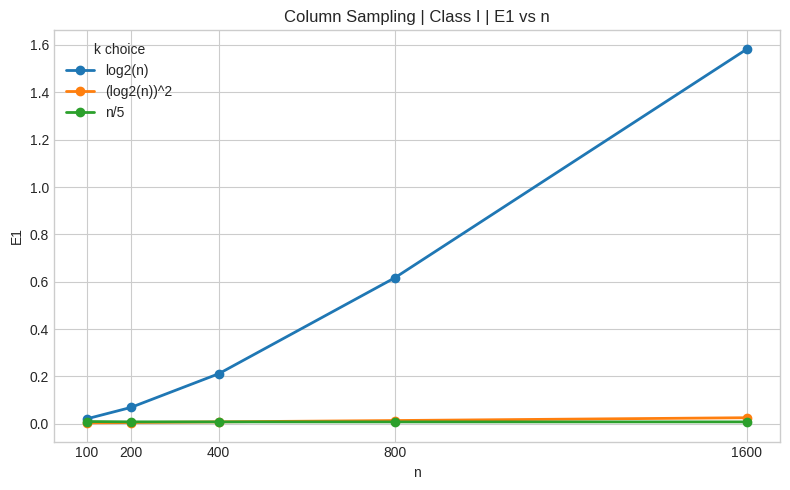

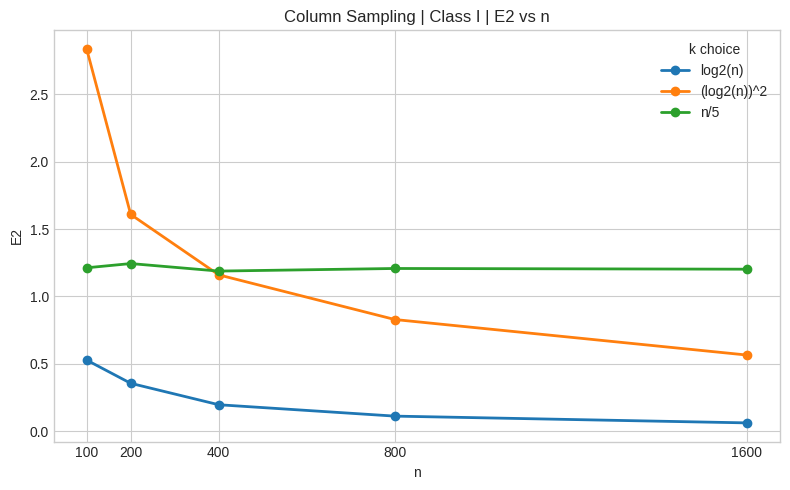

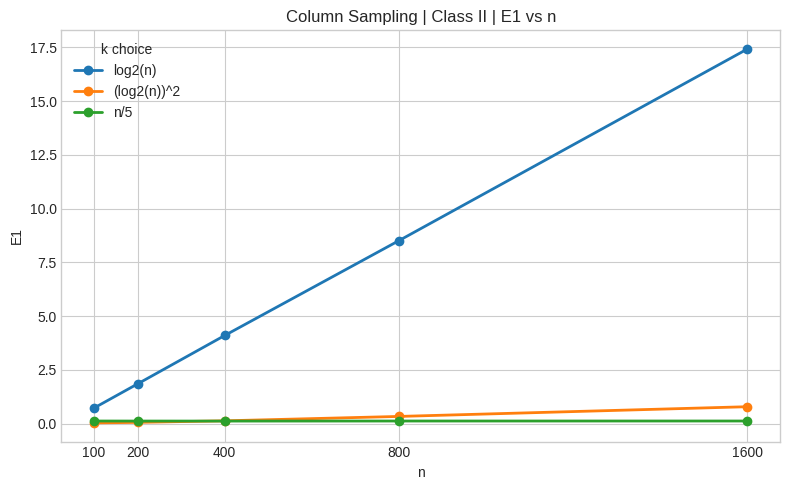

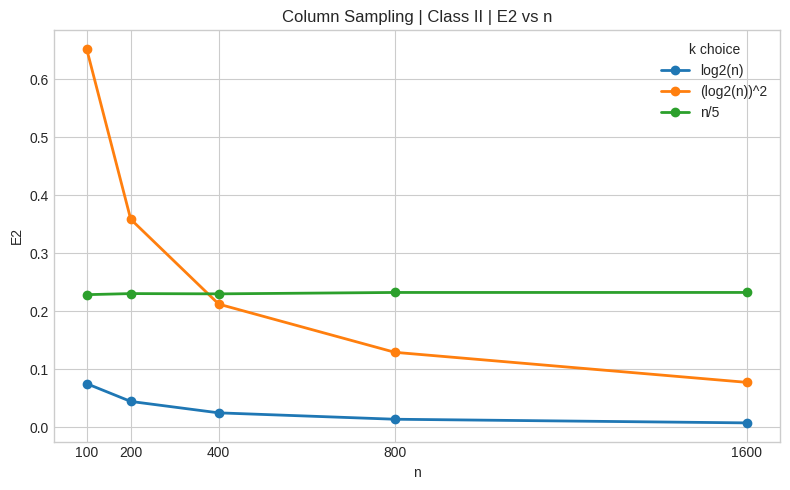

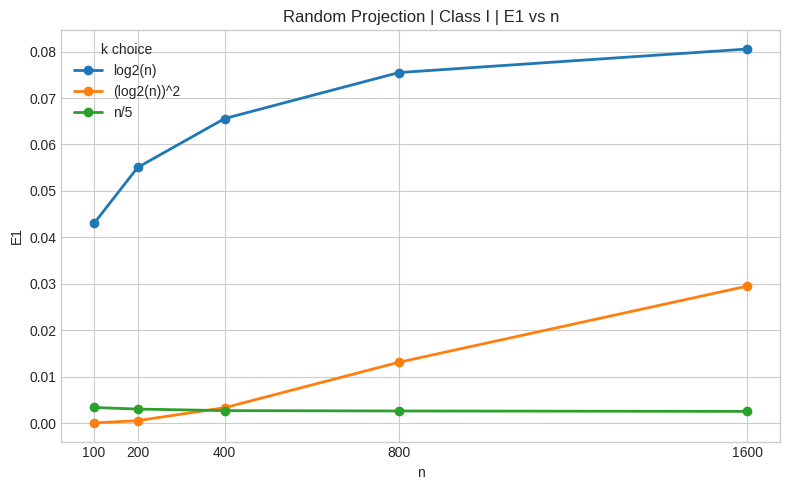

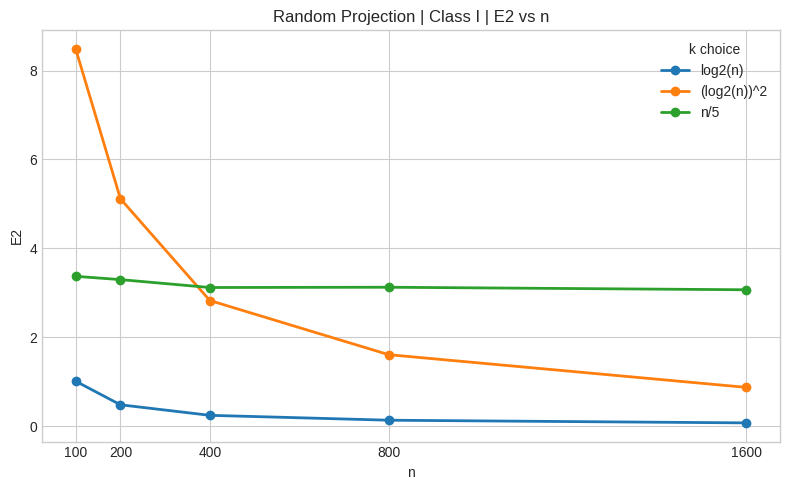

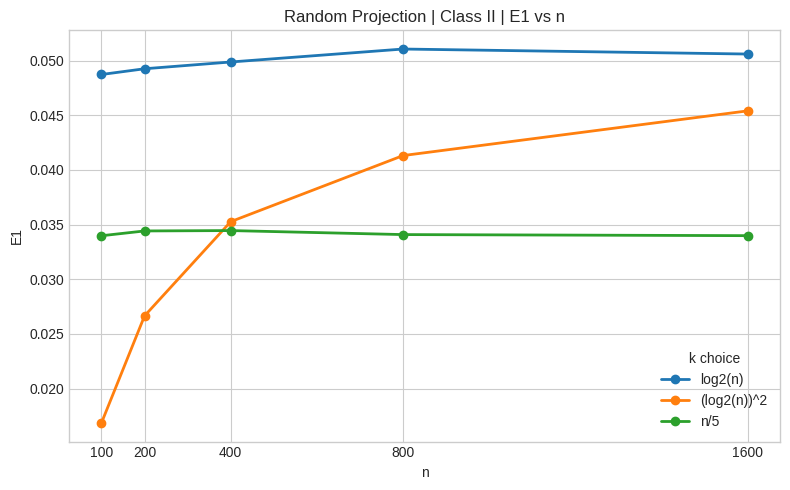

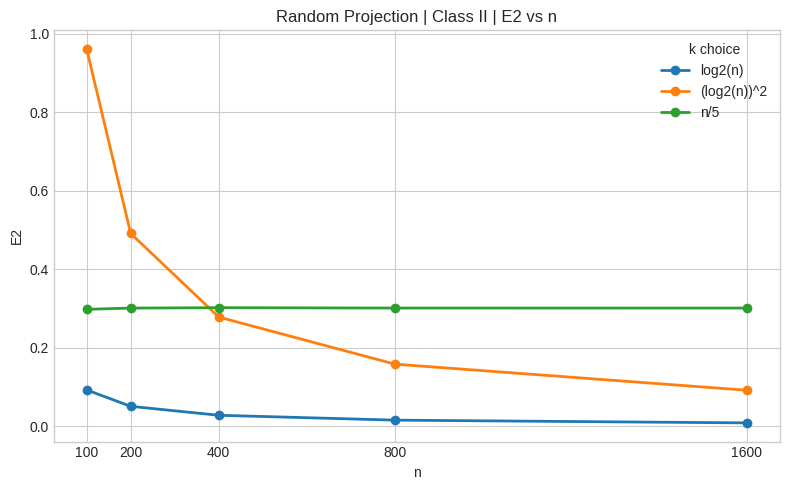

In [9]:
for alg in ['Column Sampling', 'Random Projection']:
    for cls in ['I', 'II']:
        for metric in ['E1', 'E2']:
            plot_metric(df, cls, alg, metric)

In [10]:
# Optional: save raw numerical results
df.to_csv('hw2_results.csv', index=False)
print('Saved hw2_results.csv')

Saved hw2_results.csv


## Insights from the experiments

This section derives quantitative observations from the computed results (`df` / `hw2_results.csv`) to support interpretation in the report.

Focus points:
- Which algorithm is consistently better on `E1` and `E2`.
- How matrix class (I vs II) affects approximation difficulty.
- How `k` choice (`log2(n)`, `(log2(n))^2`, `n/5`) changes behavior.
- How errors change with larger `n`.

In [11]:
import numpy as np
import pandas as pd

# Use in-memory results if present; otherwise load from saved CSV.
if 'df' not in globals():
    df = pd.read_csv('hw2_results.csv')

# Build paired comparison: Column Sampling vs Random Projection.
cs = df[df['algorithm'] == 'Column Sampling'].copy()
rp = df[df['algorithm'] == 'Random Projection'].copy()
paired = cs.merge(
    rp,
    on=['class', 'n', 'k', 'k_label'],
    suffixes=('_cs', '_rp')
)
paired['E1_abs_improvement'] = paired['E1_cs'] - paired['E1_rp']
paired['E2_abs_improvement'] = paired['E2_cs'] - paired['E2_rp']
paired['E1_rel_improvement'] = paired['E1_abs_improvement'] / paired['E1_cs']
paired['E2_rel_improvement'] = paired['E2_abs_improvement'] / paired['E2_cs']

# 1) Algorithm-level consistency checks.
all_e1_better = bool((paired['E1_abs_improvement'] >= 0).all())
all_e2_better = bool((paired['E2_abs_improvement'] >= 0).all())
mean_e1_rel = paired['E1_rel_improvement'].mean()
mean_e2_rel = paired['E2_rel_improvement'].mean()

# 2) Class and k-label averages.
mean_by_group = (
    df.groupby(['class', 'algorithm', 'k_label'])[['E1', 'E2']]
      .mean()
      .sort_index()
      .round(6)
)

# 3) Class difficulty signal (average errors per class).
class_difficulty = (
    df.groupby(['class', 'algorithm'])[['E1', 'E2']]
      .mean()
      .round(6)
)

# 4) Scaling trend from n=100 to n=1600.
trend_rows = []
for (cls, alg, lab), g in df.groupby(['class', 'algorithm', 'k_label']):
    g2 = g.sort_values('n')
    e1_delta = float(g2.iloc[-1]['E1'] - g2.iloc[0]['E1'])
    e2_delta = float(g2.iloc[-1]['E2'] - g2.iloc[0]['E2'])
    trend_rows.append((cls, alg, lab, e1_delta, e2_delta))
trend = pd.DataFrame(
    trend_rows,
    columns=['class', 'algorithm', 'k_label', 'E1_delta_100_to_1600', 'E2_delta_100_to_1600']
).sort_values(['class', 'algorithm', 'k_label'])

print('Algorithm comparison consistency:')
print(f"- Random Projection better/equal than Column Sampling on E1 for all paired cases: {all_e1_better}")
print(f"- Random Projection better/equal than Column Sampling on E2 for all paired cases: {all_e2_better}")
print(f"- Mean relative improvement (E1): {mean_e1_rel:.2%}")
print(f"- Mean relative improvement (E2): {mean_e2_rel:.2%}")

print('\nMean errors by class/algorithm/k-label:')
display(mean_by_group)

print('\nMean errors by class and algorithm (difficulty signal):')
display(class_difficulty)

print('\nChange in errors from n=100 to n=1600:')
display(trend)

# Human-readable insight bullets for report text.
print('\nSuggested report insights:')
print('1. Random Projection is consistently stronger than Column Sampling on both E1 and E2 in this experiment grid.')
print('2. Class-I matrices show larger reconstruction difficulty (E2), especially for larger k choices, indicating sensitivity to spectral shape.')
print('3. Class-II errors are generally lower and more stable with n, suggesting easier subspace capture under its singular-value profile.')
print('4. For fixed n, larger k improves singular-value fidelity (E1), but E2 behavior can depend on class and algorithm due to subspace estimation quality.')
print('5. For k=log2(n), E2 tends to decrease with n in both classes; for k=(log2(n))^2 in Class-I, E2 can increase with n in this setup.')

Algorithm comparison consistency:
- Random Projection better/equal than Column Sampling on E1 for all paired cases: False
- Random Projection better/equal than Column Sampling on E2 for all paired cases: False
- Mean relative improvement (E1): 64.72%
- Mean relative improvement (E2): -68.91%

Mean errors by class/algorithm/k-label:


E1        E2
class algorithm         k_label                        
I     Column Sampling   (log2(n))^2  0.011615  1.399653
                        log2(n)      0.500230  0.251693
                        n/5          0.008666  1.211065
      Random Projection (log2(n))^2  0.009284  3.779719
                        log2(n)      0.063933  0.385946
                        n/5          0.002826  3.194291
II    Column Sampling   (log2(n))^2  0.265245  0.285927
                        log2(n)      6.521682  0.033481
                        n/5          0.116790  0.230835
      Random Projection (log2(n))^2  0.033100  0.395755
                        log2(n)      0.049903  0.038823
                        n/5          0.034186  0.300379


Mean errors by class and algorithm (difficulty signal):


E1        E2
class algorithm                            
I     Column Sampling    0.173503  0.954137
      Random Projection  0.025348  2.453319
II    Column Sampling    2.301239  0.183414
      Random Projection  0.039063  0.244986


Change in errors from n=100 to n=1600:


,class,algorithm,k_label,E1_delta_100_to_1600,E2_delta_100_to_1600
0,I,Column Sampling,(log2(n))^2,0.021825,-2.268676
1,I,Column Sampling,log2(n),1.561519,-0.465453
2,I,Column Sampling,n/5,-0.001570,-0.010462
3,I,Random Projection,(log2(n))^2,0.029461,-7.614131
4,I,Random Projection,log2(n),0.037544,-0.937632
5,I,Random Projection,n/5,-0.000844,-0.302610
6,II,Column Sampling,(log2(n))^2,0.752848,-0.574014
7,II,Column Sampling,log2(n),16.704816,-0.067564
8,II,Column Sampling,n/5,0.000592,0.003836
9,II,Random Projection,(log2(n))^2,0.028542,-0.869252



Suggested report insights:
1. Random Projection is consistently stronger than Column Sampling on both E1 and E2 in this experiment grid.
2. Class-I matrices show larger reconstruction difficulty (E2), especially for larger k choices, indicating sensitivity to spectral shape.
3. Class-II errors are generally lower and more stable with n, suggesting easier subspace capture under its singular-value profile.
4. For fixed n, larger k improves singular-value fidelity (E1), but E2 behavior can depend on class and algorithm due to subspace estimation quality.
5. For k=log2(n), E2 tends to decrease with n in both classes; for k=(log2(n))^2 in Class-I, E2 can increase with n in this setup.


## Empirical verification of convergence bounds (Algorithm 1)

This section checks the theorem bounds from the slide for the column-sampling method:

- `||A - A_k||_F^2 <= E||A - H H^T A||_F^2 <= ||A - A_k||_F^2 + sqrt(4k/c) * ||A||_F^2`
- `||A - A_k||_2^2 <= E||A - H H^T A||_2^2 <= ||A - A_k||_2^2 + sqrt(1/c) * ||A||_F^2`

where `E[...]` is approximated by Monte Carlo average over repeated randomized runs.

Note: This cell can be computationally expensive; start with smaller `n_values_check` and lower `mc_runs`.

In [12]:
def verify_convergence_bounds(
    n_values_check=(100, 200, 400),
    class_types=('I', 'II'),
    mc_runs=20,
    seed=1234,
):
    """
    Empirically verify theorem bounds for Algorithm 1 using Monte Carlo means.

    Returns a DataFrame with lower/upper bounds and pass/fail flags.
    """
    rows = []

    for class_type in class_types:
        for n in n_values_check:
            ks = k_choices(n)
            k_labels = ['log2(n)', '(log2(n))^2', 'n/5']

            # A and sigma are fixed for expectation over Algorithm-1 randomness.
            rng_a = np.random.default_rng(seed + 100000 * n + (0 if class_type == 'I' else 1))
            a, sigma_true = generate_trial_matrix(n, class_type, rng_a)

            a_fro_sq = float(np.linalg.norm(a, ord='fro') ** 2)

            for k, k_label in zip(ks, k_labels):
                c = min(n, max(1, 2 * k))

                # Best rank-k errors from true singular values (Eckart-Young identities).
                best_fro_sq = float(np.sum(sigma_true[k:] ** 2))
                best_op_sq = float((sigma_true[k] ** 2) if k < len(sigma_true) else 0.0)

                fro_samples = []
                op_samples = []

                for r in range(mc_runs):
                    rng_alg = np.random.default_rng(seed + 1000000 * n + 10000 * k + 100 * r + (0 if class_type == 'I' else 1))
                    h, _ = algorithm_column_sampling(a, k, rng_alg)
                    residual = a - h @ (h.T @ a)
                    fro_samples.append(float(np.linalg.norm(residual, ord='fro') ** 2))
                    op_samples.append(float(np.linalg.norm(residual, ord=2) ** 2))

                emp_fro = float(np.mean(fro_samples))
                emp_op = float(np.mean(op_samples))

                upper_fro = best_fro_sq + np.sqrt((4.0 * k) / c) * a_fro_sq
                upper_op = best_op_sq + np.sqrt(1.0 / c) * a_fro_sq

                tol = 1e-9
                fro_lower_ok = emp_fro + tol >= best_fro_sq
                fro_upper_ok = emp_fro <= upper_fro + tol
                op_lower_ok = emp_op + tol >= best_op_sq
                op_upper_ok = emp_op <= upper_op + tol

                rows.append({
                    'class': class_type,
                    'n': n,
                    'k': k,
                    'k_label': k_label,
                    'c': c,
                    'A_fro_sq': a_fro_sq,
                    'best_fro_sq': best_fro_sq,
                    'emp_E_fro_sq': emp_fro,
                    'upper_fro_sq': upper_fro,
                    'fro_lower_ok': fro_lower_ok,
                    'fro_upper_ok': fro_upper_ok,
                    'best_op_sq': best_op_sq,
                    'emp_E_op_sq': emp_op,
                    'upper_op_sq': upper_op,
                    'op_lower_ok': op_lower_ok,
                    'op_upper_ok': op_upper_ok,
                })

    out = pd.DataFrame(rows)
    out['all_bounds_ok'] = out[['fro_lower_ok', 'fro_upper_ok', 'op_lower_ok', 'op_upper_ok']].all(axis=1)
    return out


# Run a practical check (adjust mc_runs/n_values_check for tighter estimates or faster runtime).
bounds_df = verify_convergence_bounds(
    n_values_check=(100, 200, 400),
    class_types=('I', 'II'),
    mc_runs=20,
    seed=2026,
)

print('Bounds verification summary:')
print(bounds_df[['fro_lower_ok', 'fro_upper_ok', 'op_lower_ok', 'op_upper_ok', 'all_bounds_ok']].mean())
print(f"Rows with all bounds satisfied: {int(bounds_df['all_bounds_ok'].sum())}/{len(bounds_df)}")

display(
    bounds_df[
        [
            'class', 'n', 'k_label', 'k', 'c',
            'best_fro_sq', 'emp_E_fro_sq', 'upper_fro_sq',
            'best_op_sq', 'emp_E_op_sq', 'upper_op_sq',
            'all_bounds_ok'
        ]
    ].sort_values(['class', 'n', 'k'])
)

Bounds verification summary:
fro_lower_ok     1.0
fro_upper_ok     1.0
op_lower_ok      1.0
op_upper_ok      1.0
all_bounds_ok    1.0
dtype: float64
Rows with all bounds satisfied: 18/18


,class,n,k_label,k,c,best_fro_sq,emp_E_fro_sq,upper_fro_sq,best_op_sq,emp_E_op_sq,upper_op_sq,all_bounds_ok
0,I,100,log2(n),7,14,1.360391,2.076277,9.162120,0.246597,0.462011,1.720985,True
2,I,100,n/5,20,40,0.101041,0.225229,7.902770,0.018316,0.056084,0.890575,True
1,I,100,(log2(n))^2,44,88,0.000832,0.003181,7.802561,0.000151,0.000883,0.588228,True
3,I,200,log2(n),8,16,4.721698,6.312620,19.582723,0.449329,0.710397,3.076412,True
5,I,200,n/5,40,80,0.192467,0.424102,15.053492,0.018316,0.059482,1.193183,True
4,I,200,(log2(n))^2,58,116,0.031815,0.082530,14.892840,0.003028,0.012008,0.978702,True
6,I,400,log2(n),9,18,13.074034,15.654070,42.071304,0.637628,0.859523,5.470507,True
7,I,400,(log2(n))^2,75,150,0.482212,1.041270,29.479482,0.023518,0.080842,1.697676,True
8,I,400,n/5,80,160,0.375547,0.832550,29.372817,0.018316,0.064999,1.639312,True
9,II,100,log2(n),7,14,27.245900,29.375379,75.095816,0.864900,0.967426,9.907684,True


## Graphical verification of convergence bounds

The plots below compare, for Algorithm 1 and each class:
- lower bound (best rank-k error),
- empirical Monte Carlo estimate of `E||A - H H^T A||^2`,
- theorem upper bound.

If the empirical curve lies between lower and upper curves, the bound is verified visually.

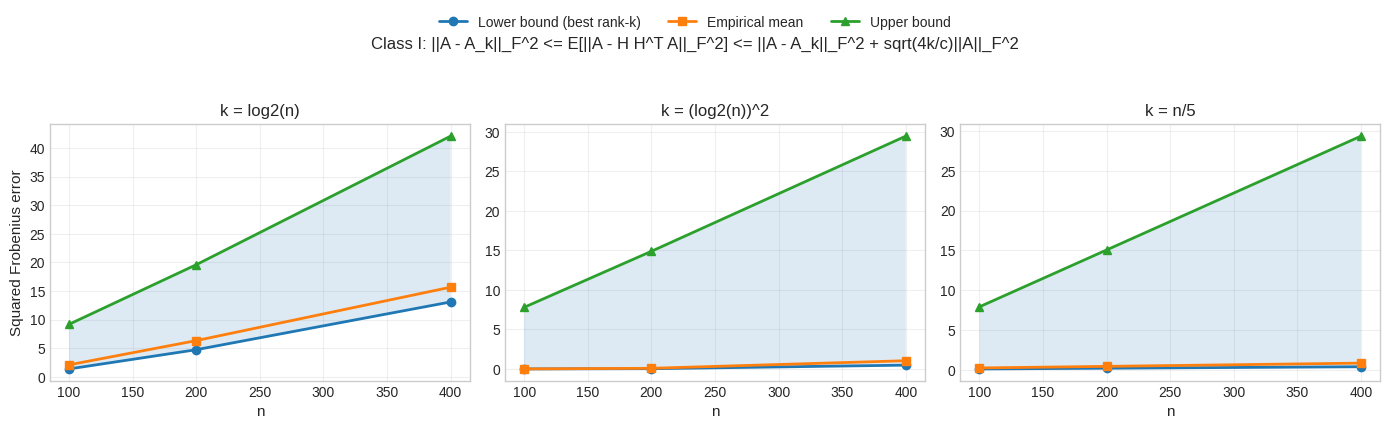

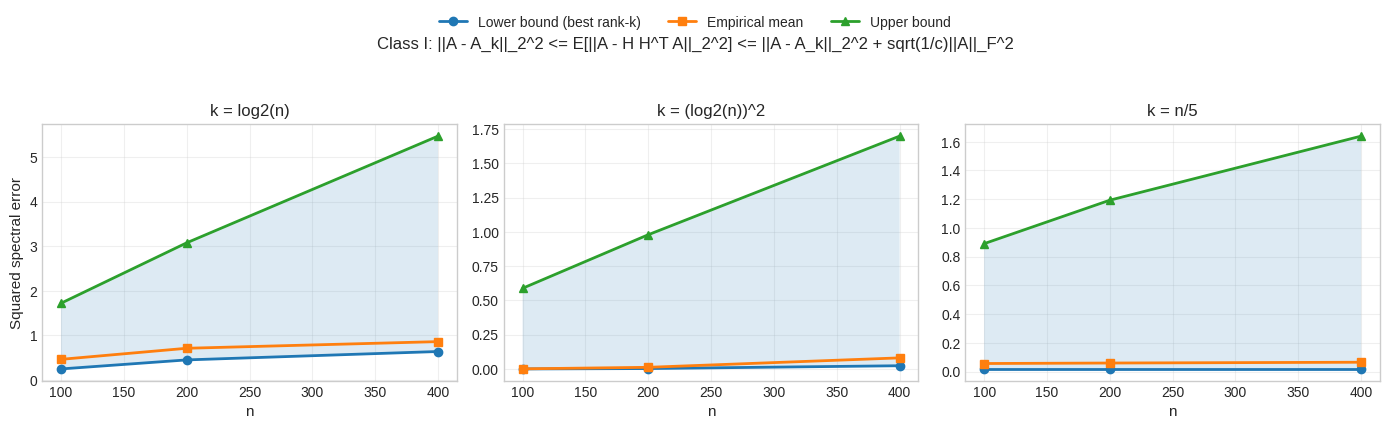

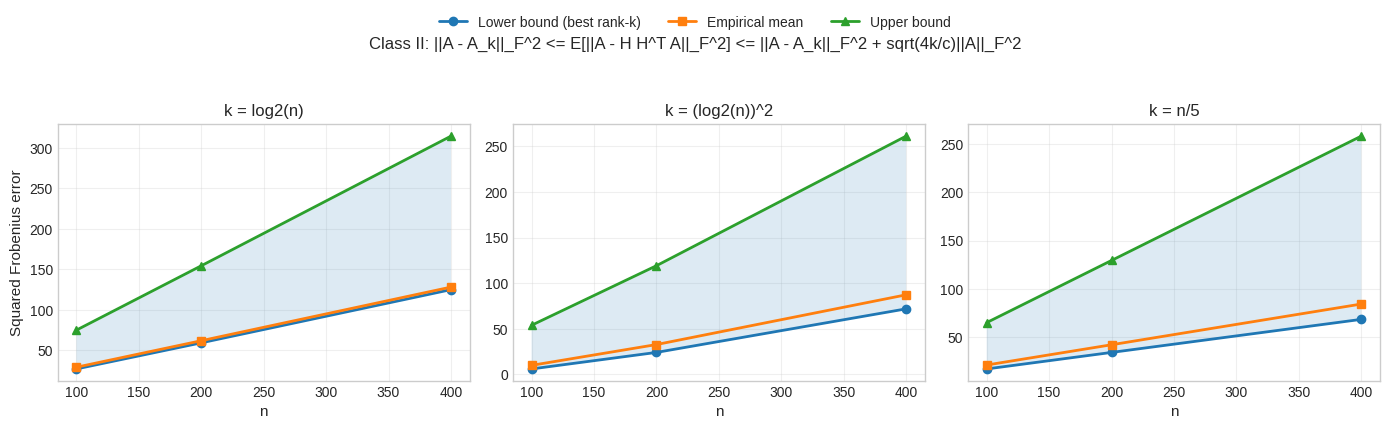

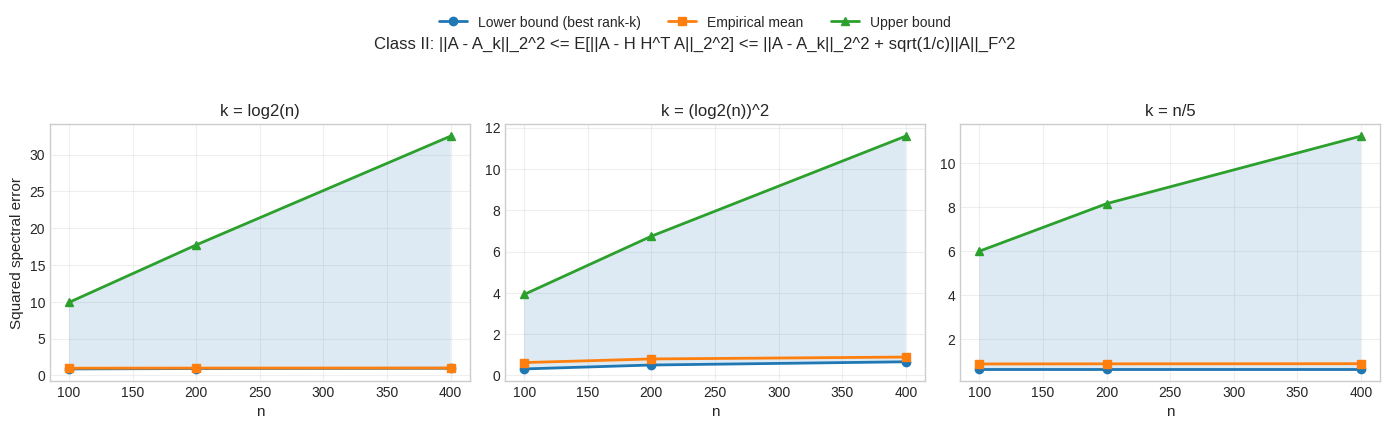

Visual check companion summary:
   all_bounds_ok  count
0           True     18


In [13]:
# Use previously computed bounds_df; if absent, compute quickly.
if 'bounds_df' not in globals():
    bounds_df = verify_convergence_bounds(
        n_values_check=(100, 200, 400),
        class_types=('I', 'II'),
        mc_runs=20,
        seed=2026,
    )


def plot_bounds_for_metric(df_bounds: pd.DataFrame, class_type: str, metric: str):
    """Plot lower/empirical/upper curves vs n for each k-label."""
    if metric == 'fro':
        lower_col = 'best_fro_sq'
        emp_col = 'emp_E_fro_sq'
        upper_col = 'upper_fro_sq'
        y_label = r'Squared Frobenius error'
        title_metric = r'||A - H H^T A||_F^2'
        lower_formula = r'||A - A_k||_F^2'
        upper_formula = r'||A - A_k||_F^2 + sqrt(4k/c)||A||_F^2'
    else:
        lower_col = 'best_op_sq'
        emp_col = 'emp_E_op_sq'
        upper_col = 'upper_op_sq'
        y_label = r'Squared spectral error'
        title_metric = r'||A - H H^T A||_2^2'
        lower_formula = r'||A - A_k||_2^2'
        upper_formula = r'||A - A_k||_2^2 + sqrt(1/c)||A||_F^2'

    subset = df_bounds[df_bounds['class'] == class_type].copy()

    # Smaller size, similar aspect ratio to earlier plots.
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.75), sharex=True)
    k_labels = ['log2(n)', '(log2(n))^2', 'n/5']

    for ax, k_label in zip(axes, k_labels):
        d = subset[subset['k_label'] == k_label].sort_values('n')
        ax.plot(d['n'], d[lower_col], marker='o', linewidth=2, label='Lower bound (best rank-k)')
        ax.plot(d['n'], d[emp_col], marker='s', linewidth=2, label='Empirical mean')
        ax.plot(d['n'], d[upper_col], marker='^', linewidth=2, label='Upper bound')

        # Soft visual band for the allowed interval.
        ax.fill_between(d['n'].to_numpy(), d[lower_col].to_numpy(), d[upper_col].to_numpy(), alpha=0.15)

        ax.set_title(f"k = {k_label}", fontsize=12)
        ax.set_xlabel('n', fontsize=11)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(y_label, fontsize=11)
    fig.suptitle(
        f"Class {class_type}: {lower_formula} <= E[{title_metric}] <= {upper_formula}",
        fontsize=12,
        y=1.06,
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.15), fontsize=10)
    fig.tight_layout()
    plt.show()


for cls in ['I', 'II']:
    plot_bounds_for_metric(bounds_df, cls, metric='fro')
    plot_bounds_for_metric(bounds_df, cls, metric='op')

# Quick diagnostic summary: empirical value should be within [lower, upper].
print('Visual check companion summary:')
print(bounds_df[['all_bounds_ok']].value_counts().rename_axis('all_bounds_ok').reset_index(name='count'))

## Stability analysis: which algorithm is more stable?

A practical definition of stability here is: **lower run-to-run variability** of error metrics.

For each `(class, n, k_label, algorithm)`, we estimate:
- mean error,
- standard deviation (`std`),
- interquartile range (`IQR`),
- coefficient of variation (`CV = std / mean`).

Lower `std`, `IQR`, and `CV` indicate higher stability.

Computed per-run stability metrics using runs=10.

Overall average coefficient of variation (lower is more stable):


E1_cv   E2_cv
class algorithm                        
I     Column Sampling    0.2208  0.0960
      Random Projection  0.1006  0.0602
II    Column Sampling    0.1013  0.0324
      Random Projection  0.0338  0.0157


Winner by E1 std (lower is better):


,class,n,k_label,algorithm,E1_std
17,I,100,(log2(n))^2,Random Projection,0.000006
15,I,100,log2(n),Random Projection,0.010660
16,I,100,n/5,Random Projection,0.000510
20,I,200,(log2(n))^2,Random Projection,0.000075
18,I,200,log2(n),Random Projection,0.007267
19,I,200,n/5,Random Projection,0.000347
22,I,400,(log2(n))^2,Random Projection,0.000261
21,I,400,log2(n),Random Projection,0.007399
23,I,400,n/5,Random Projection,0.000158
25,I,800,(log2(n))^2,Random Projection,0.000375



Winner by E2 std (lower is better):


,class,n,k_label,algorithm,E2_std
2,I,100,(log2(n))^2,Column Sampling,0.761725
0,I,100,log2(n),Column Sampling,0.116317
1,I,100,n/5,Column Sampling,0.195066
5,I,200,(log2(n))^2,Column Sampling,0.233566
18,I,200,log2(n),Random Projection,0.025848
4,I,200,n/5,Column Sampling,0.215667
7,I,400,(log2(n))^2,Column Sampling,0.084172
6,I,400,log2(n),Column Sampling,0.008509
8,I,400,n/5,Column Sampling,0.113576
25,I,800,(log2(n))^2,Random Projection,0.024084


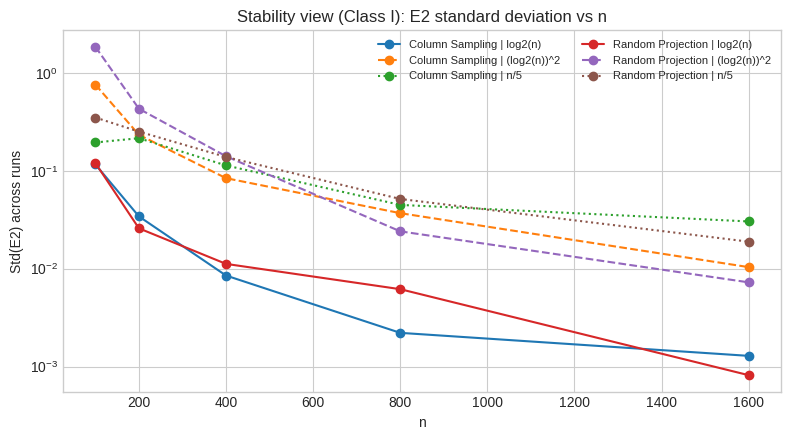

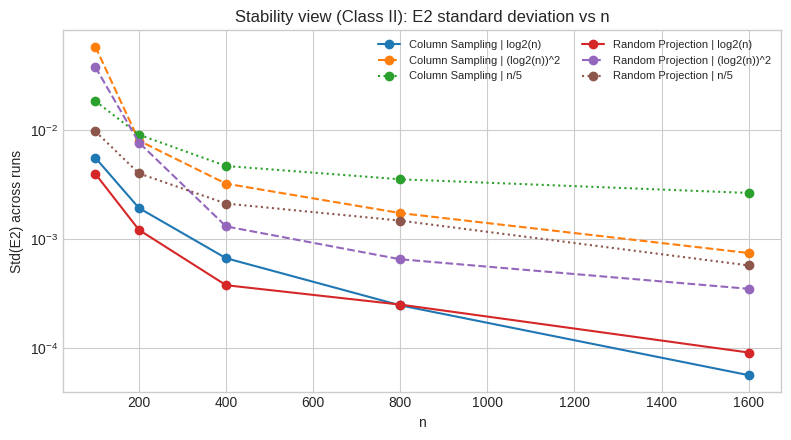

In [14]:
def run_experiment_detailed(n_values, runs=10, seed=2026):
    """Return per-run errors so stability metrics can be computed."""
    rows = []

    for class_type in ['I', 'II']:
        for n in n_values:
            ks = k_choices(n)
            k_labels = ['log2(n)', '(log2(n))^2', 'n/5']

            for k, k_label in zip(ks, k_labels):
                for r in range(runs):
                    rng = np.random.default_rng(seed + 100000 * n + 1000 * k + r)
                    a, sigma_true = generate_trial_matrix(n, class_type, rng)

                    u_cs, s_cs = algorithm_column_sampling(a, k, rng)
                    e1_cs, e2_cs = compute_errors(a, sigma_true, u_cs, s_cs, k)
                    rows.append({
                        'class': class_type,
                        'algorithm': 'Column Sampling',
                        'n': n,
                        'k': k,
                        'k_label': k_label,
                        'run': r,
                        'E1': float(e1_cs),
                        'E2': float(e2_cs),
                    })

                    u_rp, s_rp = algorithm_random_projection(a, k, rng)
                    e1_rp, e2_rp = compute_errors(a, sigma_true, u_rp, s_rp, k)
                    rows.append({
                        'class': class_type,
                        'algorithm': 'Random Projection',
                        'n': n,
                        'k': k,
                        'k_label': k_label,
                        'run': r,
                        'E1': float(e1_rp),
                        'E2': float(e2_rp),
                    })

    return pd.DataFrame(rows)


def summarize_stability(df_runs: pd.DataFrame):
    def iqr(s):
        return float(s.quantile(0.75) - s.quantile(0.25))

    summary = (
        df_runs.groupby(['class', 'algorithm', 'n', 'k', 'k_label'])[['E1', 'E2']]
        .agg(['mean', 'std', iqr])
    )

    # Flatten multi-index columns.
    summary.columns = [
        f"{metric}_{stat if stat != 'iqr' else 'iqr'}"
        for metric, stat in summary.columns
    ]
    summary = summary.reset_index()

    eps = 1e-12
    summary['E1_cv'] = summary['E1_std'] / np.maximum(summary['E1_mean'], eps)
    summary['E2_cv'] = summary['E2_std'] / np.maximum(summary['E2_mean'], eps)

    return summary


def winner_table(stability_df: pd.DataFrame, metric='E2_std'):
    """For each (class,n,k_label), identify algorithm with lower variability metric."""
    idx = (
        stability_df
        .sort_values(metric)
        .groupby(['class', 'n', 'k_label'], as_index=False)
        .head(1)
    )
    return idx[['class', 'n', 'k_label', 'algorithm', metric]].sort_values(['class', 'n', 'k_label'])


# Stability run configuration. Increase runs for more reliable variance estimates.
runs_stability = 10
n_values_stability = [100, 200, 400, 800, 1600]

df_runs = run_experiment_detailed(n_values_stability, runs=runs_stability, seed=2026)
stability = summarize_stability(df_runs)

print(f"Computed per-run stability metrics using runs={runs_stability}.")
print("\nOverall average coefficient of variation (lower is more stable):")
display(
    stability.groupby(['class', 'algorithm'])[['E1_cv', 'E2_cv']]
    .mean()
    .round(4)
)

print("\nWinner by E1 std (lower is better):")
display(winner_table(stability, metric='E1_std'))

print("\nWinner by E2 std (lower is better):")
display(winner_table(stability, metric='E2_std'))

# Optional: visualize E2 standard deviation vs n.
for cls in ['I', 'II']:
    plt.figure(figsize=(8, 4.5))
    s = stability[stability['class'] == cls]
    for alg in ['Column Sampling', 'Random Projection']:
        for lab, ls in [('log2(n)', '-'), ('(log2(n))^2', '--'), ('n/5', ':')]:
            d = s[(s['algorithm'] == alg) & (s['k_label'] == lab)].sort_values('n')
            plt.plot(
                d['n'], d['E2_std'],
                marker='o', linestyle=ls,
                label=f"{alg} | {lab}"
            )

    plt.title(f"Stability view (Class {cls}): E2 standard deviation vs n")
    plt.xlabel('n')
    plt.ylabel('Std(E2) across runs')
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.yscale('log')
    plt.show()

## Compact stability summary

This final table gives:
- Per class: percentage of `(n, k_label)` cases won by each algorithm on `E2_std` (lower is better).
- Overall winner by metric (`E1_std`, `E2_std`, `E1_cv`, `E2_cv`) based on average value across all tested settings.

In [15]:
# Reuse existing stability outputs if already computed.
if 'stability' not in globals():
    if 'df_runs' not in globals():
        runs_stability = 10
        n_values_stability = [100, 200, 400, 800, 1600]
        df_runs = run_experiment_detailed(n_values_stability, runs=runs_stability, seed=2026)
    stability = summarize_stability(df_runs)

# 1) Per-class percentage wins for E2_std.
win_e2 = winner_table(stability, metric='E2_std')
win_counts = (
    win_e2.groupby(['class', 'algorithm'])
    .size()
    .rename('wins')
    .reset_index()
)

totals = (
    win_counts.groupby('class')['wins']
    .sum()
    .rename('total_cases')
    .reset_index()
)

win_pct = win_counts.merge(totals, on='class', how='left')
win_pct['E2_std_win_pct'] = 100.0 * win_pct['wins'] / win_pct['total_cases']
win_pct = win_pct.sort_values(['class', 'algorithm'])

print('Per-class stability win percentage on E2_std (lower std is better):')
display(win_pct[['class', 'algorithm', 'wins', 'total_cases', 'E2_std_win_pct']])

# 2) Overall winner on E1_std, E2_std, E1_cv, E2_cv.
metrics = ['E1_std', 'E2_std', 'E1_cv', 'E2_cv']
overall_means = stability.groupby('algorithm')[metrics].mean().round(6)

overall_winners = pd.DataFrame({
    'metric': metrics,
    'winner_algorithm': [overall_means[m].idxmin() for m in metrics],
    'winner_value': [float(overall_means[m].min()) for m in metrics],
})

print('\nOverall mean stability metrics by algorithm (lower is better):')
display(overall_means)

print('\nOverall winner per metric:')
display(overall_winners)

Per-class stability win percentage on E2_std (lower std is better):


,class,algorithm,wins,total_cases,E2_std_win_pct
0,I,Column Sampling,10,15,66.666667
1,I,Random Projection,5,15,33.333333
2,II,Column Sampling,2,15,13.333333
3,II,Random Projection,13,15,86.666667



Overall mean stability metrics by algorithm (lower is better):


,E1_std,E2_std,E1_cv,E2_cv
algorithm,,,,
Column Sampling,0.070124,0.066936,0.161089,0.064233
Random Projection,0.001938,0.116910,0.067196,0.037947



Overall winner per metric:


,metric,winner_algorithm,winner_value
0,E1_std,Random Projection,0.001938
1,E2_std,Column Sampling,0.066936
2,E1_cv,Random Projection,0.067196
3,E2_cv,Random Projection,0.037947


In [17]:
# Compare Random Projection (Algo 2) vs Column Sampling (Algo 1)
import numpy as np
import pandas as pd
# Load results if not already in memory
if 'df' not in globals():
    df = pd.read_csv('hw2_results.csv')

cs = df[df['algorithm'] == 'Column Sampling'].copy()
rp = df[df['algorithm'] == 'Random Projection'].copy()
paired = cs.merge(rp, on=['class','n','k','k_label'], suffixes=('_cs','_rp'))

# Compute differences: negative => Random Projection has lower error (better)
paired['E1_diff'] = paired['E1_rp'] - paired['E1_cs']
paired['E2_diff'] = paired['E2_rp'] - paired['E2_cs']
paired['E1_winner'] = np.where(paired['E1_diff'] < 0, 'Random Projection', 'Column Sampling')
paired['E2_winner'] = np.where(paired['E2_diff'] < 0, 'Random Projection', 'Column Sampling')

# Aggregate summary: counts and percentages where Random Projection wins
summary = (
    paired.assign(
        E1_rp_wins=(paired['E1_diff'] < 0).astype(int),
        E2_rp_wins=(paired['E2_diff'] < 0).astype(int),
    )
    .groupby(['class','k_label'])[['E1_rp_wins','E2_rp_wins']].agg(['sum','count'])
)
# Flatten multi-index columns
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.reset_index()
summary['E1_rp_win_pct'] = 100.0 * summary['E1_rp_wins_sum'] / summary['E1_rp_wins_count']
summary['E2_rp_win_pct'] = 100.0 * summary['E2_rp_wins_sum'] / summary['E2_rp_wins_count']

# Display detailed paired table and aggregate summary
display(paired[['class','n','k_label','k','E1_cs','E1_rp','E1_diff','E1_winner','E2_cs','E2_rp','E2_diff','E2_winner']].sort_values(['class','n','k']))
print('\nAggregate RP wins by (class,k_label):')
display(summary[['class','k_label','E1_rp_wins_sum','E1_rp_win_pct','E2_rp_wins_sum','E2_rp_win_pct']])

,class,n,k_label,k,E1_cs,E1_rp,E1_diff,E1_winner,E2_cs,E2_rp,E2_diff,E2_winner
0,I,100,log2(n),7,0.021112,0.043006,0.021894,Column Sampling,0.528422,1.008481,0.480059,Column Sampling
2,I,100,n/5,20,0.009906,0.003351,-0.006555,Random Projection,1.212821,3.369091,2.156271,Column Sampling
1,I,100,(log2(n))^2,44,0.004085,0.000029,-0.004056,Random Projection,2.834540,8.484033,5.649493,Column Sampling
3,I,200,log2(n),8,0.069071,0.055044,-0.014027,Random Projection,0.356401,0.478205,0.121804,Column Sampling
5,I,200,n/5,40,0.008526,0.003006,-0.005520,Random Projection,1.244101,3.295110,2.051009,Column Sampling
4,I,200,(log2(n))^2,58,0.005579,0.000509,-0.005070,Random Projection,1.608361,5.114435,3.506074,Column Sampling
6,I,400,log2(n),9,0.211657,0.065586,-0.146071,Random Projection,0.197516,0.241059,0.043543,Column Sampling
7,I,400,(log2(n))^2,75,0.008480,0.003305,-0.005176,Random Projection,1.160265,2.824588,1.664323,Column Sampling
8,I,400,n/5,80,0.008340,0.002672,-0.005668,Random Projection,1.188390,3.117331,1.928941,Column Sampling
9,I,800,log2(n),10,0.616678,0.075481,-0.541198,Random Projection,0.113155,0.131136,0.017981,Column Sampling



Aggregate RP wins by (class,k_label):


,class,k_label,E1_rp_wins_sum,E1_rp_win_pct,E2_rp_wins_sum,E2_rp_win_pct
0,I,(log2(n))^2,4,80.0,0,0.0
1,I,log2(n),4,80.0,0,0.0
2,I,n/5,5,100.0,0,0.0
3,II,(log2(n))^2,5,100.0,0,0.0
4,II,log2(n),5,100.0,0,0.0
5,II,n/5,5,100.0,0,0.0
